SCENARIO 1 – BAGGING

In [1]:
!pip install imbalanced-learn

Decision Tree Accuracy: 0.9473684210526315
Bagging Accuracy: 0.9824561403508771


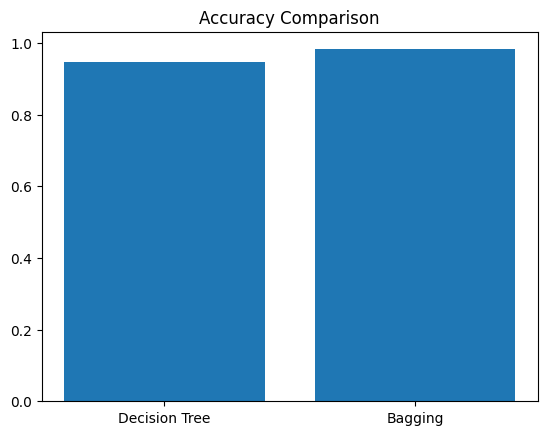

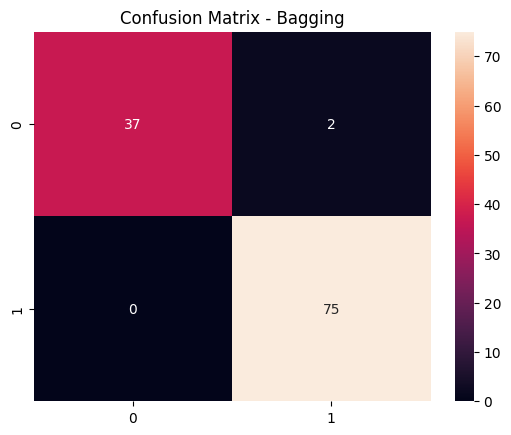

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (use sklearn built-in diabetes-like dataset)
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print("Decision Tree Accuracy:", acc_dt)
print("Bagging Accuracy:", acc_bag)

# Bar Graph
plt.bar(["Decision Tree", "Bagging"], [acc_dt, acc_bag])
plt.title("Accuracy Comparison")
plt.show()

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True, fmt='d')
plt.title("Confusion Matrix - Bagging")
plt.show()

SCENARIO 2 – BOOSTING

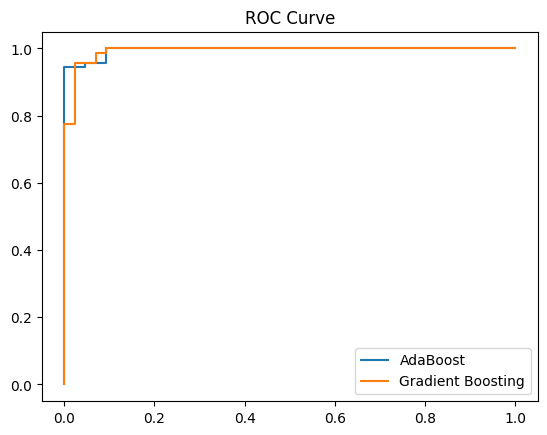

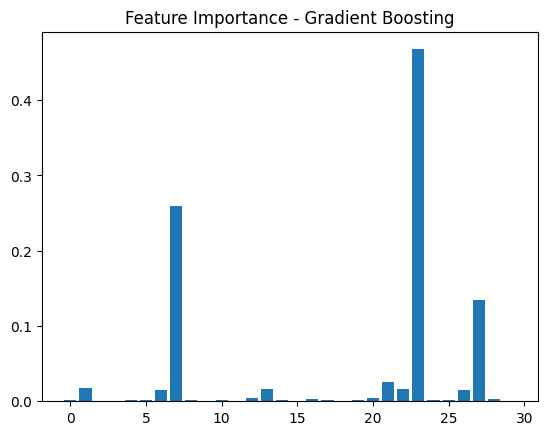

In [3]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc

# Using same dataset for simplicity
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# AdaBoost
ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# ROC Curve
y_prob_ada = ada.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

fpr1, tpr1, _ = roc_curve(y_test, y_prob_ada)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr1, tpr1, label="AdaBoost")
plt.plot(fpr2, tpr2, label="Gradient Boosting")
plt.legend()
plt.title("ROC Curve")
plt.show()

# Feature Importance
plt.bar(range(len(gb.feature_importances_)), gb.feature_importances_)
plt.title("Feature Importance - Gradient Boosting")
plt.show()

SCENARIO 3 – RANDOM FOREST

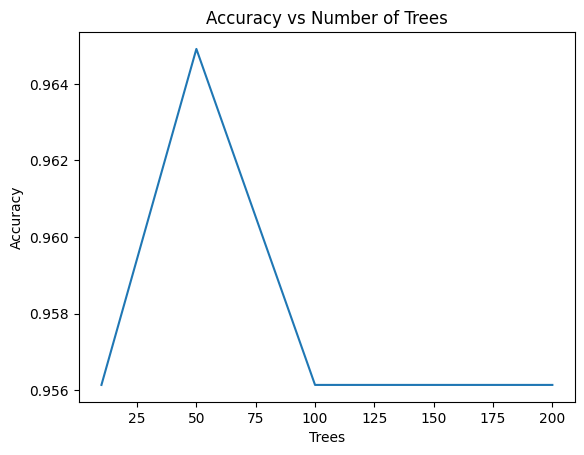

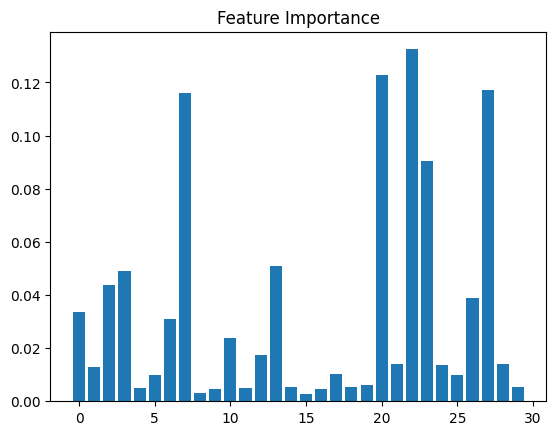

In [4]:
from sklearn.ensemble import RandomForestClassifier

trees = [10, 50, 100, 200]
accuracies = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Graph
plt.plot(trees, accuracies)
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Trees")
plt.ylabel("Accuracy")
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.bar(range(len(rf.feature_importances_)), rf.feature_importances_)
plt.title("Feature Importance")
plt.show()

SCENARIO 4 – STACKING

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

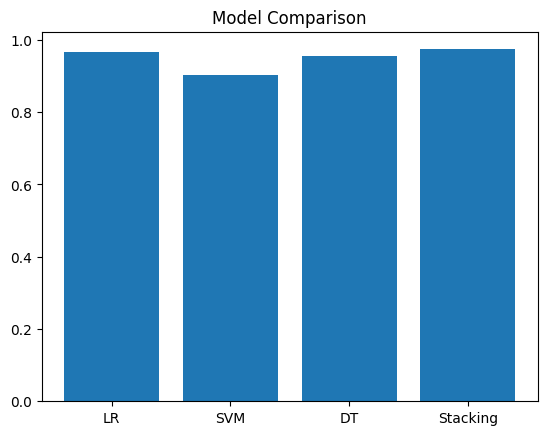

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier

# Base models
base_models = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

# Stacking
stack = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression()
)

# Train
for name, model in base_models:
    model.fit(X_train, y_train)

stack.fit(X_train, y_train)

# Accuracy comparison
scores = []

for name, model in base_models:
    scores.append(accuracy_score(y_test, model.predict(X_test)))

scores.append(accuracy_score(y_test, stack.predict(X_test)))

labels = ["LR", "SVM", "DT", "Stacking"]

plt.bar(labels, scores)
plt.title("Model Comparison")
plt.show()

SCENARIO 5 – SMOTE

Before SMOTE: [439 130]
After SMOTE: [439 439]


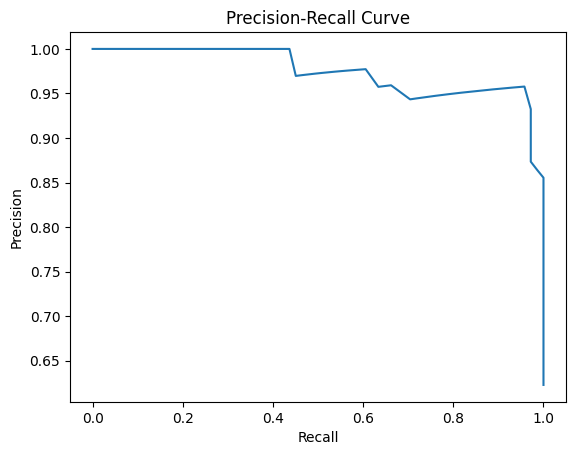

In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, precision_recall_curve

# Create imbalance artificially
y_imbalanced = np.copy(y)
y_imbalanced[:400] = 0

# Before SMOTE
print("Before SMOTE:", np.bincount(y_imbalanced))

# Apply SMOTE
sm = SMOTE()
X_res, y_res = sm.fit_resample(X, y_imbalanced)

print("After SMOTE:", np.bincount(y_res))

# Train model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_before = rf.predict(X_test)

rf.fit(X_res, y_res)
y_pred_after = rf.predict(X_test)

# Precision-Recall Curve
y_scores = rf.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()